In [5]:
import pandas as pd

file_path = 'fileslist.txt'

try:
    df_files = pd.read_csv(file_path, sep='\t', encoding='utf-8')
    df_files['ПутьКФайлу'] = df_files['ПутьКФайлу'].str.replace('ä', 'a', regex=False)
    df_grouped = df_files.groupby('Ссылка').agg({
        'ПутьКФайлу': lambda x: '; '.join(x.astype(str)),
        'Наименование': lambda x: '; '.join(x.astype(str).unique()),
        'Расширение': lambda x: '; '.join(x.astype(str).unique()),
        'Ссылка': 'count'
    })

    df_grouped = df_grouped.rename(columns={'Ссылка': 'Количество'}).reset_index()
    df_grouped = df_grouped.sort_values(by='Количество', ascending=False)

    print("Данные сгруппированы (Наименования только уникальные):")
    print(df_grouped.head())

    df_grouped.to_excel('grouped_unique_names.xlsx', index=False)
    print("\nФайл 'grouped_unique_names.xlsx' готов.")

except FileNotFoundError:
    print(f"Ошибка: Файл {file_path} не найден.")
except Exception as e:
    print(f"Произошла ошибка: {e}")

Данные сгруппированы (Наименования только уникальные):
                                    Ссылка  \
2643  Заказ покупателя 19161 от 06.10.2023   
2639  Заказ покупателя 19154 от 05.10.2023   
7873   Заказ покупателя 5430 от 30.10.2025   
2611  Заказ покупателя 19120 от 02.10.2023   
6844   Заказ покупателя 4275 от 08.08.2025   

                                             ПутьКФайлу  \
2643  20231010\HLrNEONYLPDSBY1_42000178_v2_appr_Стра...   
2639  20231005\HLrNEONYLPDSRUS1_42000141_V2_appr_fin...   
7873  20251030\R\Монтажная область 2.png; 20251030\М...   
2611  20231002\HLrNEDLPCHCRUS1_42000174_MattOPV_V2_С...   
6844  20250808\10Монтажная область 1.png; 20250808\9...   

                                           Наименование Расширение  Количество  
2643  HLrNEONYLPDSBY1_42000178_v2_appr_Страница_01; ...        jpg          15  
2639  HLrNEONYLPDSRUS1_42000141_V2_appr_final_eye-C_...        jpg          15  
7873  Монтажная область 2; Монтажная область 3; Монт...        png    

In [6]:
df_files = df_grouped

In [7]:
from google.colab import drive
import os
import zipfile

# Монтируем Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os
import zipfile

zip_path = '/content/drive/My Drive/source.zip'
extract_path = '/content/data/'

if not os.path.exists(extract_path):
    os.makedirs(extract_path)

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            # Шаг 1: Извлекаем имя файла в байтах
            # ZIP хранит имена в cp437 по стандарту
            try:
                raw_name = info.filename.encode('cp437')
                # Шаг 2: Декодируем из IBM866 (DOS)
                fixed_name = raw_name.decode('ibm866')
            except:
                # Если не вышло, оставляем как есть (для папок или уже нормальных имен)
                fixed_name = info.filename

            # Формируем путь
            target_path = os.path.join(extract_path, fixed_name)

            # Создаем структуру папок
            if info.is_dir():
                os.makedirs(target_path, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(target_path), exist_ok=True)
                # Извлекаем содержимое
                with z.open(info) as source, open(target_path, "wb") as target:
                    target.write(source.read())

    print(f"✅ Готово! Файл 'ЊҐв Ўа®­е' стал 'Мет бронх'.")
else:
    print("❌ Архив не найден.")

✅ Готово! Файл 'ЊҐв Ўа®­е' стал 'Мет бронх'.


In [9]:
# Группируем по колонке 'Ссылка' и считаем количество строк в каждой группе
link_counts = df_files.groupby('Ссылка').size().reset_index(name='Количество')

# Сортируем по убыванию, чтобы увидеть самые частые ссылки сверху
link_counts = link_counts.sort_values(by='Количество', ascending=False)

print(link_counts.head())

                                   Ссылка  Количество
8820   Заказ покупателя 997 от 31.10.2024           1
0       Заказ покупателя 10 от 05.06.2024           1
1      Заказ покупателя 100 от 15.08.2024           1
2     Заказ покупателя 1000 от 31.10.2024           1
3     Заказ покупателя 1001 от 31.10.2024           1


In [10]:
import pandas as pd
import re

df_merged = pd.read_csv('df_merged.csv', encoding='utf-8')

def filter_dataframe(df):
    df_filtered = df.copy()
    resource_mask = df_filtered['РесурсПредприятия'].str.contains('Датрон|ПЛ', na=False, case=False)
    material_mask = df_filtered['Материал'].str.contains('Латунь|Алюминий|Стеклотекстолит', na=False, case=False)
    unit_mask = ~df_filtered['ЕдиницаИзмерения'].str.contains('усл|ч', na=False, case=False)
    df_filtered = df_filtered[resource_mask & material_mask & unit_mask]
    return df_filtered

df_filtered = filter_dataframe(df_merged)

def fix_date_parsing_correct(df):
    df_fixed = df.copy()
    for col in ['Старт', 'Финиш']:
        if col in df_fixed.columns:
            df_fixed[f'{col}_original'] = df_fixed[col]
            df_fixed[col] = pd.to_datetime(df_fixed[col], format='%d.%m.%Y %H:%M:%S', errors='coerce')
    return df_fixed

df_filtered = fix_date_parsing_correct(df_filtered)

df_filtered['Длительность_минуты'] = (df_filtered['Финиш'] - df_filtered['Старт']).dt.total_seconds() / 60
df_filtered['Длительность_минуты'] = df_filtered['Длительность_минуты'].abs()
df_clean = df_filtered[
    (df_filtered['Длительность_минуты'].notnull()) &
    (df_filtered['Длительность_минуты'] > 0)
].copy()

def extract_first_3_words(text):
    if pd.isna(text):
        return None
    text = re.sub(r'\s{2,}', ' ', text).replace('_', ' ')
    return " ".join(text.split()[:3])

df_clean['Номенклатура_3слова'] = df_clean['Номенклатура'].astype(str).apply(extract_first_3_words)
df_merged = df_clean

df_files['Ссылка'] = df_files['Ссылка'].str.strip()
df_merged['Ссылка_order'] = df_merged['Ссылка_order'].str.strip()

df_final = pd.merge(
    df_files,
    df_merged,
    left_on='Ссылка',
    right_on='Ссылка_order',
    how='inner'
)

print(f"Количество строк после объединения df_merged: {len(df_merged)}")
print(f"Количество строк после объединения df_files: {len(df_files)}")
print(f"Количество строк после объединения df_final: {len(df_final)}")

/tmp/ipykernel_448/121436548.py:5: DtypeWarning: Columns (9,28,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv('df_merged.csv', encoding='utf-8')


Количество строк после объединения df_merged: 28966
Количество строк после объединения df_files: 8821
Количество строк после объединения df_final: 23327


In [11]:
df_merged = df_merged[df_merged['Номенклатура'].str.contains('клише', na=False, case=False)]

print(f"Количество строк после фильтрации 'клише': {len(df_merged)}")

Количество строк после фильтрации 'клише': 15062


In [12]:
df_files['Ссылка'] = df_files['Ссылка'].str.strip()
df_merged['Ссылка_order'] = df_merged['Ссылка_order'].str.strip()

df_final = pd.merge(
    df_files,
    df_merged,
    left_on='Ссылка',
    right_on='Ссылка_order',
    how='inner'
)

print(f"Количество строк после объединения df_merged: {len(df_merged)}")
print(f"Количество строк после объединения df_files: {len(df_files)}")
print(f"Количество строк после объединения df_final: {len(df_final)}")

/tmp/ipykernel_448/3418005529.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['Ссылка_order'] = df_merged['Ссылка_order'].str.strip()


Количество строк после объединения df_merged: 15062
Количество строк после объединения df_files: 8821
Количество строк после объединения df_final: 12159


In [13]:
df_merged[df_merged['Ссылка_order'].str.contains('16376', na=False)]

,Ссылка_order,Дата_order,ВалютаДокумента,Контрагент,Курс,Проект,ВидПродукции,Номенклатура,ЕдиницаИзмерения,Количество_order,...,Времяработы,Брак,Пробноеклише,ПутьКфайлам,Необходимытесты,ТестыВыполнены,Старт_original,Финиш_original,Длительность_минуты,Номенклатура_3слова
0,Заказ покупателя 16376 от 09.01.2023,09.01.2023 9:45:09,руб.,ГРАФОБАЛ-ДОН ООО,1.0,Multi Тabak,Упаковка,Клише A 1_23 TEST_MT_H+K-59119S0059-SSP-M-ARM...,шт,1,...,NaN,NaN,NaN,016376 штамп Datron,NaN,NaN,11.01.2023 10:57:03,11.01.2023 12:56:12,119.15,Клише A 1


In [14]:
df_final[df_final['Ссылка'].str.contains('16376', na=False)]

,Ссылка,ПутьКФайлу,Наименование,Расширение,Количество,Ссылка_order,Дата_order,ВалютаДокумента,Контрагент,Курс,...,Времяработы,Брак,Пробноеклише,ПутьКфайлам,Необходимытесты,ТестыВыполнены,Старт_original,Финиш_original,Длительность_минуты,Номенклатура_3слова
7765,Заказ покупателя 16376 от 09.01.2023,20230109\MT_H+K-59119S0059-SSP-M-ARM_final (00...,MT_H+K-59119S0059-SSP-M-ARM_final (002),jpg,1,Заказ покупателя 16376 от 09.01.2023,09.01.2023 9:45:09,руб.,ГРАФОБАЛ-ДОН ООО,1.0,...,NaN,NaN,NaN,016376 штамп Datron,NaN,NaN,11.01.2023 10:57:03,11.01.2023 12:56:12,119.15,Клише A 1


In [ ]:
# Сохранение в CSV
df_final.to_csv('result_final.csv', index=False, encoding='utf-8-sig', sep=';')

print("Файл 'result_final.csv' успешно сохранен!")

Файл 'result_final.csv' успешно сохранен!


In [ ]:
count_equal_1 = (df_final['Количество'] == 1).sum()
count_not_equal_1 = (df_final['Количество'] > 1).sum()

print(f"Количество ссылок с одним файлом (ОК): {count_equal_1}")
print(f"Количество ссылок с несколькими файлами (Дубли): {count_not_equal_1}")

total = len(df_final)
if total > 0:
    print(f"\nДоля дублей: {(count_not_equal_1 / total) * 100:.2f}%")

Количество ссылок с одним файлом (ОК): 11022
Количество ссылок с несколькими файлами (Дубли): 1137

Доля дублей: 9.35%


In [ ]:
df_single = df_final[df_final['Количество'] == 1].copy()

df_single = df_single.drop(columns=['Количество'])

df_single.to_excel('final_single_files.xlsx', index=False)

In [ ]:
import os

base_path = '/content/data/source'

def check_file_exists(relative_path):
    clean_path = str(relative_path).replace('\\', '/')
    full_path = os.path.join(base_path, clean_path)
    return os.path.isfile(full_path)

df_single['ФайлНайдено'] = df_single['ПутьКФайлу'].apply(check_file_exists)

missing_files = df_single[df_single['ФайлНайдено'] == False]
found_count = df_single['ФайлНайдено'].sum()
total_count = len(df_single)

print(f"📊 Итоги проверки:")
print(f"✅ Найдено файлов: {found_count} из {total_count}")
print(f"❌ Отсутствует: {total_count - found_count}")

if not missing_files.empty:
    print("\nПримеры отсутствующих путей:")
    print(missing_files['ПутьКФайлу'].tolist())

📊 Итоги проверки:
✅ Найдено файлов: 11020 из 11022
❌ Отсутствует: 2

Примеры отсутствующих путей:
['20231108\\Профессор-5_2500.tif', '20231031\\AB_Gourmet_CaneléFlambé X4 (002).jpg']


In [ ]:
df_single_clean = df_single[df_single['ФайлНайдено'] == True].copy()

df_single_clean = df_single_clean.drop(columns=['ФайлНайдено'])

df_single_clean = df_single_clean.reset_index(drop=True)

print(f"🧹 Очистка завершена:")
print(f"Было строк: {len(df_single)}")
print(f"Стало строк: {len(df_single_clean)}")
print(f"Удалено «пустых» записей: {len(df_single) - len(df_single_clean)}")

df_single = df_single_clean

🧹 Очистка завершена:
Было строк: 11022
Стало строк: 11020
Удалено «пустых» записей: 2


In [ ]:
len(df_single)

11020

In [ ]:
from PIL import Image
import os

base_path = '/content/data/source'

def is_image_really_valid(relative_path):
    clean_path = str(relative_path).replace('\\', '/')
    full_path = os.path.join(base_path, clean_path)

    if not os.path.isfile(full_path):
        return False

    try:
        with Image.open(full_path) as img:
            if img.size[0] <= 1 or img.size[1] <= 1:
                return False

            img = img.convert("RGB")
            img.thumbnail((28, 28))

            aspect_ratio = max(img.size) / min(img.size)
            if aspect_ratio > 200: # Слишком узкие полоски игнорируем
                return False

        return True
    except Exception as e:
        return False

# Применяем максимально глубокую проверку
print("Начинаю глубокую валидацию изображений (декодирование пикселей)...")
df_single['КартинкаВалидна'] = df_single['ПутьКФайлу'].apply(is_image_really_valid)

# Очищаем датасет
df_bad = df_single[df_single['КартинкаВалидна'] == False]
df_single = df_single[df_single['КартинкаВалидна'] == True].copy()
df_single = df_single.drop(columns=['КартинкаВалидна']).reset_index(drop=True)

print(f"📊 Результаты глубокой проверки:")
print(f"✅ Валидных изображений: {len(df_single)}")
print(f"❌ Удалено подозрительных/битых: {len(df_bad)}")

if len(df_bad) > 0:
    print("\nПримеры удаленных файлов:")
    print(df_bad['ПутьКФайлу'].head().tolist())

Начинаю глубокую валидацию изображений (декодирование пикселей)...
📊 Результаты глубокой проверки:
✅ Валидных изображений: 11020
❌ Удалено подозрительных/битых: 0


подготовка данных и разбиение (Train/Test)

Адаптация Dataset и Модели Qwen2.5-VL

In [ ]:
# удаляем конфликтующие версии
!pip uninstall -y transformers

# устанавливаем transformers прямо с GitHub (где есть поддержка Qwen2.5)
!pip install git+https://github.com/huggingface/transformers@main

# остальные библиотеки
!pip install -U "accelerate>=0.34.0" "peft>=0.13.2" "bitsandbytes" "datasets" "pandas" "pillow" "qwen-vl-utils" "protobuf"

Found existing installation: transformers 5.0.1.dev0
Uninstalling transformers-5.0.1.dev0:
  Successfully uninstalled transformers-5.0.1.dev0
  Cloning https://github.com/huggingface/transformers (to revision main) to /tmp/pip-req-build-tufwbx_8
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers /tmp/pip-req-build-tufwbx_8
  Resolved https://github.com/huggingface/transformers to commit b8a1c69b9681049eebd151446455484b45cc8603
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.0.1.dev0-py3-none-any.whl size=11351182 sha256=ea533f7ee85e33fd7002fba49108f43ae026d84e87fb198b74a8472bac29d68b
  Stored in directory: /tmp/pip-ephem-wheel-cache-tfuyr_fz/wheels/39/86/e8/b741dec268128a8c6b0b51669c589bd02f8dfe94b1e5b1d79a
Successfully built transformers


In [ ]:
import torch
import pandas as pd
import re
from pathlib import Path
from dataclasses import dataclass
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model
from qwen_vl_utils import process_vision_info

# --- 1. ПОДГОТОВКА ТЕКСТОВОГО КОНТЕКСТА ---
features_cols = [
    'РесурсПредприятия', 'Объем', 'Цена', 'ДлинаРеальная', 'ОперацияНТК',
    'ШиринаРеальная', 'Проект', 'Количество_order', 'Контрагент',
    'Номенклатура_3слова', 'ДлинаПродукции', 'ШиринаПродукции', 'Материал'
]

def create_smart_context(row):
    # Добавляем глоссарий, чтобы модель понимала суть признаков
    glossary = (
        "Industrial Context Definitions:\n"
        "- 'РесурсПредприятия': Machinery/Workstation ID.\n"
        "- 'ОперацияНТК': Specific technological step.\n"
        "- 'Объем', 'ДлинаРеальная': Physical workload metrics.\n\n"
    )
    context = glossary + "Current Job Characteristics:\n"
    for col in features_cols:
        if col in row:
            context += f"- {col}: {row[col]}\n"
    return context

# Применяем контекст к исходному df_final
df_single['text_context'] = df_single.apply(create_smart_context, axis=1)

# Разбиваем на Train и Test
train_df, test_df = train_test_split(df_single, test_size=0.2, random_state=42)

# --- 2. ПУТИ И СООБЩЕНИЯ ---
BASE_IMAGE_DIR = Path("data/source")

In [ ]:
MIN_PIXELS = 128 * 28
MAX_PIXELS = 28 * 28 * 256

def build_qwen_message(image_relative_path, context, duration=None):
    clean_path = str(image_relative_path).replace('\\', '/')
    full_path = BASE_IMAGE_DIR / clean_path

    prompt = f"{context}\nTask: Predict 'Длительность_минуты'. Output ONLY the numerical value."
    #Лучший для точности
    #prompt = (
    #    f"{context}\n"
    #    "Task: Estimate the manufacturing time for this cliché.\n"
    #    "1. Analyze the visual complexity of the drawing (line density, small details).\n"
    #    "2. Consider the material and physical dimensions provided in the context.\n"
    #    "3. Predict 'Длительность_минуты'.\n"
    #    "Format your output as: 'Analysis: [brief description] | Duration: [numerical value]'"
    #)
    #Если важна мелкая гравировка
    #prompt = (
    #    f"{context}\n"
    #    "Task: Act as an industrial engineer. Look at the image and the technical data.\n"
    #    "Estimate the engraving time in minutes. Take into account that intricate patterns "
    #    "and small fonts increase 'Длительность_минуты' significantly.\n"
    #    "Output ONLY the numerical value in minutes."
    #)
    #С указанием диапазона
    #prompt = (
    #    f"{context}\n"
    #    "Task: Predict the machining duration ('Длительность_минуты') for this job.\n"
    #    "Constraint: Your output must be a float or integer representing minutes.\n"
    #    "Think step-by-step about the volume of material to be removed based on the image.\n"
    #    "Result:"
    #)
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": f"file://{full_path.resolve()}",
                    "min_pixels": MIN_PIXELS,
                    "max_pixels": MAX_PIXELS,
                },
                {"type": "text", "text": prompt},
            ],
        }
    ]
    if duration is not None:
        messages.append({"role": "assistant", "content": [{"type": "text", "text": str(duration)}]})
    return messages

# --- 3. КЛАСС ДАТАСЕТА ---
class QwenRegressionDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "image_path": row["ПутьКФайлу"],
            "context": row["text_context"],
            "duration": row["Длительность_минуты"]
        }

# --- 4. ИНИЦИАЛИЗАЦИЯ МОДЕЛИ ---
MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"

# Настройка квантования (исправляет ошибку bitsandbytes)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

# Загрузка модели с исправленным параметром dtype
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    dtype=torch.float16, # Вместо устаревшего torch_dtype
    quantization_config=bnb_config
)
processor = AutoProcessor.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Применяем LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    #target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)

# Создаем объекты датасетов
train_ds = QwenRegressionDataset(train_df)
test_ds = QwenRegressionDataset(test_df)

print(f"Datasets ready. Train size: {len(train_ds)}, Test size: {len(test_ds)}")

Datasets ready. Train size: 8816, Test size: 2204


In [ ]:
import torch
from PIL import Image
import numpy as np

@dataclass
class QwenRegressionCollator:
    processor: any

    def __call__(self, batch):
        messages = []
        image_inputs = []

        for x in batch:
            full_path = os.path.join(base_path, str(x["image_path"]).replace('\\', '/'))
            try:
                # Пытаемся открыть и подготовить картинку
                img = Image.open(full_path).convert("RGB")

                # Проверка на экстремальное соотношение сторон (защита от ValueError)
                w, h = img.size
                if w / h > 100 or h / w > 100:
                    # Если картинка слишком узкая, заменяем её на белый квадрат 224x224
                    img = Image.new('RGB', (224, 224), color=(255, 255, 255))

                image_inputs.append(img)
                messages.append(build_qwen_message(x["image_path"], x["context"], duration=x.get("duration")))

            except Exception as e:
                print(f"⚠️ Ошибка на файле {x['image_path']}: {e}. Использую заглушку.")
                # Если файл совсем не открылся, создаем заглушку
                img = Image.new('RGB', (224, 224), color=(0, 0, 0))
                image_inputs.append(img)
                messages.append(build_qwen_message(x["image_path"], x["context"], duration=x.get("duration")))

        # Обработка визуальной части
        # Важно: здесь мы передаем уже открытые объекты Image, а не пути
        try:
            visions = [process_vision_info(m) for m in messages]
            # Заменяем пути в visions на наши подготовленные image_inputs (PIL объекты)
            for i in range(len(visions)):
                visions[i][0] = image_inputs[i]

            curr_image_inputs = [v[0] for v in visions]

            texts = [
                self.processor.apply_chat_template(m, tokenize=False, add_generation_prompt=False)
                for m in messages
            ]

            inputs = self.processor(
                text=texts,
                images=curr_image_inputs,
                padding=True,
                return_tensors="pt",
                # Установите безопасные лимиты
                min_pixels=28*28,
                max_pixels=28*28*512
            ).to(model.device)

            # Генерация labels (ваш старый код без изменений)
            labels = inputs["input_ids"].clone()
            labels[inputs["attention_mask"] == 0] = -100

            # Маскирование промпта...
            prompt_msgs = [build_qwen_message(x["image_path"], x["context"], duration=None) for x in batch]
            prompt_texts = [self.processor.apply_chat_template(m, tokenize=False, add_generation_prompt=True) for m in prompt_msgs]
            prompt_inputs = self.processor(text=prompt_texts, images=curr_image_inputs, padding=True, return_tensors="pt")
            p_lens = prompt_inputs["attention_mask"].sum(dim=1)

            for i, length in enumerate(p_lens):
                safe_len = min(length, labels.shape[1])
                labels[i, :safe_len] = -100

            inputs["labels"] = labels
            return inputs

        except Exception as e:
            print(f"🚨 Критическая ошибка в процессоре: {e}")
            raise e
collator = QwenRegressionCollator(processor)

In [ ]:
@dataclass
class QwenRegressionCollator:
    processor: any

    def __call__(self, batch):
        # Используем build_qwen_message вместо build_messages
        # Передаем: путь к файлу, текстовый контекст и длительность (если есть)
        messages = [
            build_qwen_message(x["image_path"], x["context"], duration=x.get("duration"))
            for x in batch
        ]

        # Обработка визуальной части (картинки)
        visions = [process_vision_info(m) for m in messages]
        image_inputs = [v[0] for v in visions]

        # Формируем текст для обучения
        texts = [
            self.processor.apply_chat_template(m, tokenize=False, add_generation_prompt=False)
            for m in messages
        ]

        # Токенизация
        inputs = self.processor(
            text=texts,
            images=image_inputs,
            padding=True,
            return_tensors="pt",
        ).to(model.device)

        # Создаем Labels (маскируем промпт, оставляем только ответ)
        labels = inputs["input_ids"].clone()
        labels[inputs["attention_mask"] == 0] = -100 # игнорируем паддинг

        # Считаем длину промпта для маскирования
        prompt_msgs = [
            build_qwen_message(x["image_path"], x["context"], duration=None)
            for x in batch
        ]
        prompt_texts = [
            self.processor.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
            for m in prompt_msgs
        ]

        # Получаем длину промптов в токенах
        prompt_inputs = self.processor(text=prompt_texts, images=image_inputs, padding=True, return_tensors="pt")
        p_lens = prompt_inputs["attention_mask"].sum(dim=1)

        # Маскируем всё, что относится к вопросу
        for i, length in enumerate(p_lens):
            safe_len = min(length, labels.shape[1])
            labels[i, :safe_len] = -100

        inputs["labels"] = labels
        return inputs

collator = QwenRegressionCollator(processor)

In [ ]:
OUT_DIR = Path("./qwen25_vqa_lora")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
from transformers import Trainer, TrainingArguments

args = TrainingArguments(
    output_dir=str(OUT_DIR),
    per_device_train_batch_size=1,         # Снизили
    gradient_accumulation_steps=16,        # Компенсировали
    gradient_checkpointing=True,           # Экономим память
    optim="paged_adamw_8bit",              # Экономим на оптимизаторе
    num_train_epochs=1,
    learning_rate=2e-4,
    warmup_steps=50,
    logging_steps=5,
    save_steps=100,
    fp16=True,                             # Убедитесь, что это включено
    remove_unused_columns=False,
    report_to="none",
    dataloader_pin_memory=False,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=collator,
)

print("Starting training for regression...")
trainer.train()

# Сохраняем результат
model.save_pretrained(OUT_DIR / "lora_adapter")
processor.save_pretrained(OUT_DIR / "processor")

Starting training for regression...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
5,1.563235
10,1.408394
15,1.260346
20,1.160040
25,1.154531
30,0.976157
35,1.025806
40,0.956373
45,0.972343
50,0.926705


['qwen25_vqa_lora/processor/processor_config.json']

In [ ]:
def parse_duration(s: str) -> float:
    """Извлекает число из ответа модели."""
    try:
        # Ищем первое попавшееся число (целое или с точкой)
        match = re.search(r"[-+]?\d*\.\d+|\d+", s)
        return float(match.group()) if match else 0.0
    except:
        return 0.0

@torch.inference_mode()
def predict_regression(df: pd.DataFrame, batch_size: int = 2) -> pd.DataFrame:
    model.eval()
    results = []

    for start in range(0, len(df), batch_size):
        chunk = df.iloc[start:start+batch_size]

        messages_list = [
            build_qwen_message(r["ПутьКФайлу"], r["text_context"], duration=None)
            for _, r in chunk.iterrows()
        ]

        texts = [processor.apply_chat_template(m, tokenize=False, add_generation_prompt=True) for m in messages_list]
        visions = [process_vision_info(m) for m in messages_list]
        image_inputs = [v[0] for v in visions]

        inputs = processor(text=texts, images=image_inputs, padding=True, return_tensors="pt").to(model.device)

        generated_ids = model.generate(**inputs, max_new_tokens=16, do_sample=False)

        # Отрезаем промпт и декодируем
        generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        output_texts = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)

        for (_, r), raw_ans in zip(chunk.iterrows(), output_texts):
            results.append({
                "Ссылка": r.get("Ссылка", ""), # Используем ваш ID
                "true_minutes": r.get("Длительность_минуты", 0),
                "pred_minutes": parse_duration(raw_ans)
            })

    return pd.DataFrame(results)

In [ ]:
from sklearn.metrics import mean_absolute_error

print("Predicting validation...")
val_results = predict_regression(test_df) # test_df из вашего split

# Добавляем колонку с путем к файлу из исходного датафрейма
# Предполагаем, что колонка в исходных данных называется 'path' или 'file_path'
val_results["ПутьКФайлу"] = test_df["path"].values

mae = mean_absolute_error(val_results["true_minutes"], val_results["pred_minutes"])
print(f"Validation MAE: {mae:.2f} minutes")

# Сохраняем финальный результат с новой колонкой
val_results.to_csv("val_predictions.csv", index=False)
print("Saved val_predictions.csv with file paths")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Predicting validation...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='le

Validation MAE: 7.23 minutes
Saved val_predictions.csv


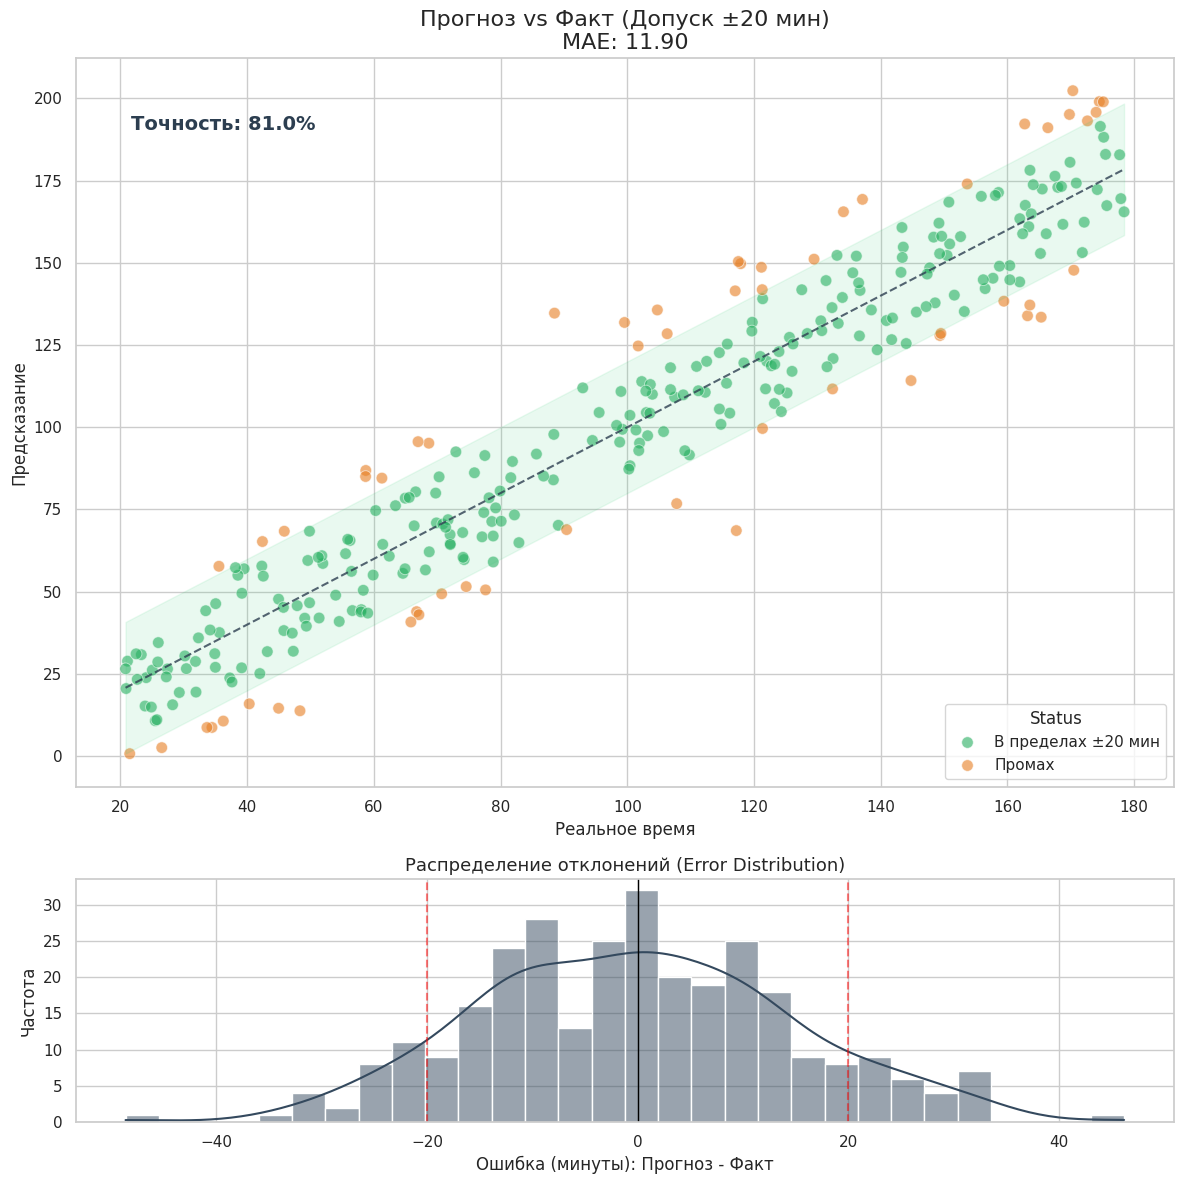

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(val_results["true_minutes"], val_results["pred_minutes"])

# 2. Визуализация с двумя графиками
def plot_advanced_analysis(df, tolerance=20):
    sns.set_theme(style="whitegrid")

    # Создаем сетку: основной график и гистограмма ошибок
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [3, 1]})

    # Расчеты
    df['error_val'] = df['pred_minutes'] - df['true_minutes']
    df['abs_error'] = df['error_val'].abs()
    df['Status'] = np.where(df['abs_error'] <= tolerance, f'В пределах ±{tolerance} мин', 'Промах')

    # --- ВЕРХНИЙ ГРАФИК: Scatter Plot ---
    sns.scatterplot(
        data=df, x="true_minutes", y="pred_minutes", hue="Status", ax=ax1,
        palette={f'В пределах ±{tolerance} мин': '#27ae60', 'Промах': '#e67e22'},
        alpha=0.6, s=70, edgecolor='w'
    )

    # Идеальная линия и коридор
    line_range = np.array([df["true_minutes"].min(), df["true_minutes"].max()])
    ax1.plot(line_range, line_range, color='#2c3e50', linestyle='--', alpha=0.8)
    ax1.fill_between(line_range, line_range - tolerance, line_range + tolerance,
                     color='#2ecc71', alpha=0.1, label='Зона допуска')

    ax1.set_title(f"Прогноз vs Факт (Допуск ±{tolerance} мин)\nMAE: {mae:.2f}", fontsize=16)
    ax1.set_xlabel("Реальное время")
    ax1.set_ylabel("Предсказание")

    # --- НИЖНИЙ ГРАФИК: Распределение ошибок ---
    sns.histplot(df['error_val'], kde=True, ax=ax2, color='#34495e', bins=30)
    ax2.axvline(0, color='black', linestyle='-', linewidth=1)
    ax2.axvline(tolerance, color='red', linestyle='--', alpha=0.5)
    ax2.axvline(-tolerance, color='red', linestyle='--', alpha=0.5)

    ax2.set_title("Распределение отклонений (Error Distribution)", fontsize=13)
    ax2.set_xlabel("Ошибка (минуты): Прогноз - Факт")
    ax2.set_ylabel("Частота")

    # Считаем % попадания
    accuracy = (df['abs_error'] <= tolerance).mean() * 100
    ax1.annotate(f"Точность: {accuracy:.1f}%", xy=(0.05, 0.9), xycoords='axes fraction',
                 fontsize=14, fontweight='bold', color='#2c3e50')

    plt.tight_layout()
    plt.show()

plot_advanced_analysis(val_results, tolerance=20)

In [4]:
import pandas as pd
import numpy as np

res_df = val_results.copy().reset_index(drop=True)
res_df['ПутьКФайлу'] = test_df['path'].values


# 2. Добавляем расчеты для анализа
res_df['error'] = res_df['pred_minutes'] - res_df['true_minutes']
res_df['abs_error'] = res_df['error'].abs()

# Добавляем текстовый статус для наглядности
tolerance = 20
res_df['status'] = res_df['abs_error'].apply(
    lambda x: '✅ OK' if x <= tolerance else '❌ FAIL'
)

# 3. Красивый вывод в консоль
print("\n=== Примеры работы модели (Допуск ±20 мин) ===")
# Используем форматирование для выравнивания колонок
print(res_df[['true_minutes', 'pred_minutes', 'error', 'status']].head(10).to_string(index=False))

# Краткая статистика по этим примерам
accuracy = (res_df['abs_error'] <= tolerance).mean() * 100
print(f"\nТочность выборки: {accuracy:.0f}%")


=== Примеры работы модели (Допуск ±20 мин) ===
 true_minutes  pred_minutes  error status
          117           140     23 ❌ FAIL
           66            77     11   ✅ OK
          107            99     -8   ✅ OK
           29            37      8   ✅ OK
           86            79     -7   ✅ OK
           75            68     -7   ✅ OK
           35            38      3   ✅ OK
          117            88    -29 ❌ FAIL
           97            71    -26 ❌ FAIL
          101            92     -9   ✅ OK

Точность выборки: 70%


/tmp/ipykernel_448/3012889068.py:78: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/3012889068.py:78: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


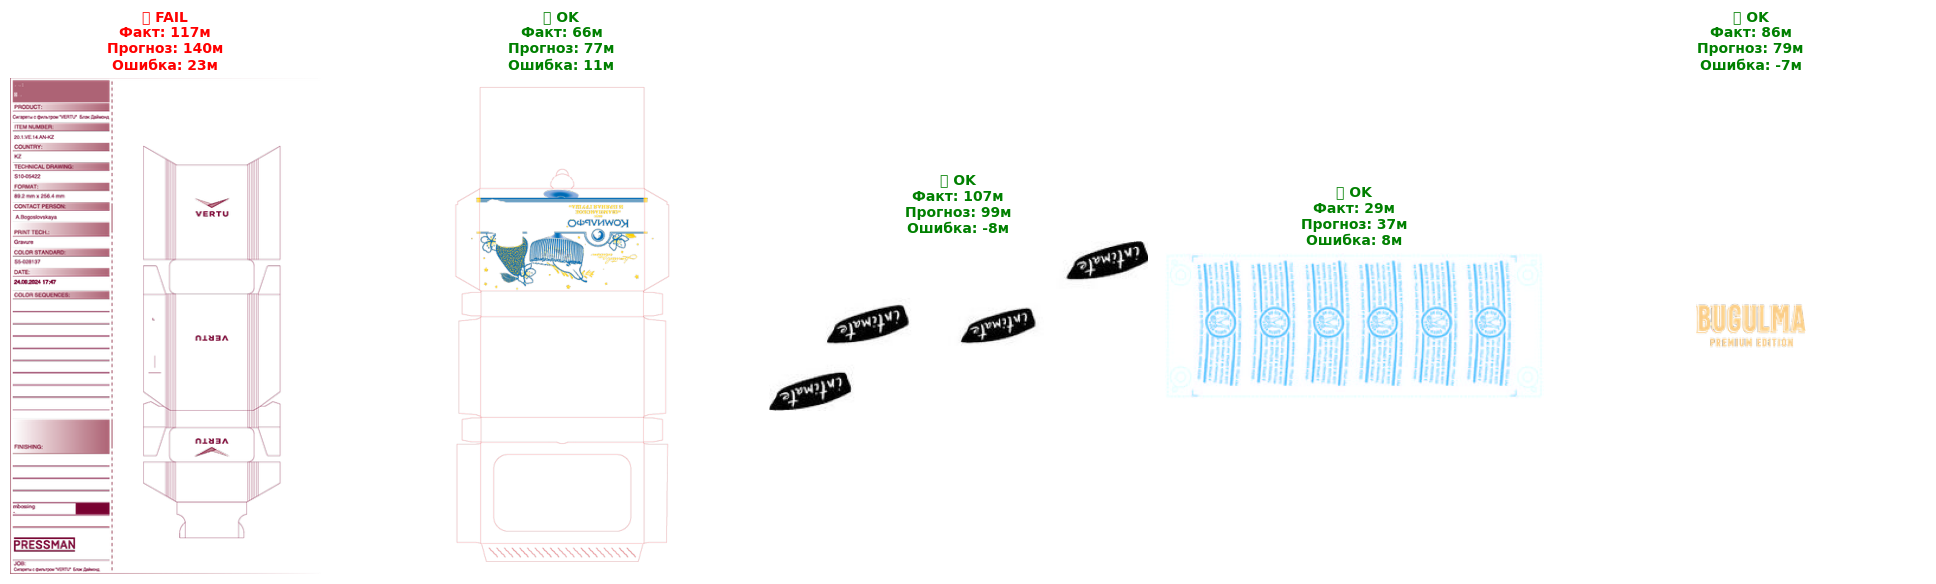


=== Статистика по выборке ===
 true_minutes  pred_minutes  error status
          117           140     23 ❌ FAIL
           66            77     11   ✅ OK
          107            99     -8   ✅ OK
           29            37      8   ✅ OK
           86            79     -7   ✅ OK


In [36]:
res_df = val_results.copy().reset_index(drop=True)
res_df['ПутьКФайлу'] = test_df['path'].values

# 2. Добавляем расчеты для анализа
res_df['error'] = res_df['pred_minutes'] - res_df['true_minutes']
res_df['abs_error'] = res_df['error'].abs()
res_df['error'] = res_df['pred_minutes'] - res_df['true_minutes']
res_df['abs_error'] = res_df['error'].abs()
tolerance = 20
res_df['status'] = res_df['abs_error'].apply(
    lambda x: '✅ OK' if x <= tolerance else '❌ FAIL'
)

# --- ЧАСТЬ 2: Поиск случайных файлов ---
path = '/content/data/source/'
n_to_show = 5  # Сколько картинок показать

try:
    # Получаем все файлы
    result = subprocess.check_output(f'find {path} -type f', shell=True)
    all_files = result.decode('utf-8').splitlines()

    # Фильтруем только картинки
    image_exts = ('.jpg', '.jpeg', '.png', '.bmp')
    all_images = [f for f in all_files if f.lower().endswith(image_exts)]

    # Выбираем случайные файлы для отображения
    selected_files = random.sample(all_images, min(n_to_show, len(all_images)))
except Exception as e:
    print(f"Ошибка поиска файлов: {e}")
    selected_files = []

# --- ЧАСТЬ 3: Визуализация ---
if not selected_files:
    print("❌ Изображения не найдены.")
else:
    plt.figure(figsize=(20, 6))

    for i, file_path in enumerate(selected_files):
        plt.subplot(1, n_to_show, i + 1)

        try:
            # Загрузка фото
            img = Image.open(file_path)
            plt.imshow(img)

            # Берем соответствующие данные из res_df для заголовка
            # (так как это рандом, просто берем данные по индексу i)
            row = res_df.iloc[i]
            color = 'green' if row['status'] == '✅ OK' else 'red'

            title = (f"{row['status']}\n"
                     f"Факт: {row['true_minutes']}м\n"
                     f"Прогноз: {row['pred_minutes']}м\n"
                     f"Ошибка: {row['error']}м")

            plt.title(title, fontsize=10, color=color, fontweight='bold')
        except:
            plt.text(0.5, 0.5, "Ошибка файла", ha='center')

        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Печать таблицы в консоль
print("\n=== Статистика по выборке ===")
print(res_df.head(n_to_show)[['true_minutes', 'pred_minutes', 'error', 'status']].to_string(index=False))